In [44]:
import pandas as pd

In [45]:
 df = pd.read_csv("../data/processed/cleaned_data.csv")

In [46]:
df.head()

,tweet,label,clean_text,label_encoded
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive,leo nimepata kitambulisho changu cha taifa asa...,2
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive,asante na tafadhali subiri tutawasiliana nawe ...,2
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral,takwimu zinaonyesha katika kila watoto wanapat...,1
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral,kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,1
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative,sio watu wazuri awa nakutana nao fa cup nawafa...,0


In [47]:
print(df.columns)

Index(['tweet', 'label', 'clean_text', 'label_encoded'], dtype='str')


In [48]:
X = df["clean_text"]
y = df["label_encoded"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

In [52]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

svm = LinearSVC(random_state=42)
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

In [53]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [54]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.60      1.00      0.75        54
           2       1.00      0.04      0.07        27

    accuracy                           0.60        91
   macro avg       0.53      0.35      0.27        91
weighted avg       0.65      0.60      0.47        91



C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

In [55]:
print("NAIVE BAYES")
print(classification_report(y_test, nb_pred))

NAIVE BAYES
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.59      1.00      0.74        54
           2       0.00      0.00      0.00        27

    accuracy                           0.59        91
   macro avg       0.20      0.33      0.25        91
weighted avg       0.35      0.59      0.44        91



C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

In [56]:
from sklearn.metrics import classification_report

print("SVM")
print(classification_report(y_test, svm_pred))

SVM
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.60      0.81      0.69        54
           2       0.28      0.19      0.22        27

    accuracy                           0.54        91
   macro avg       0.29      0.33      0.31        91
weighted avg       0.44      0.54      0.48        91



C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\katle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

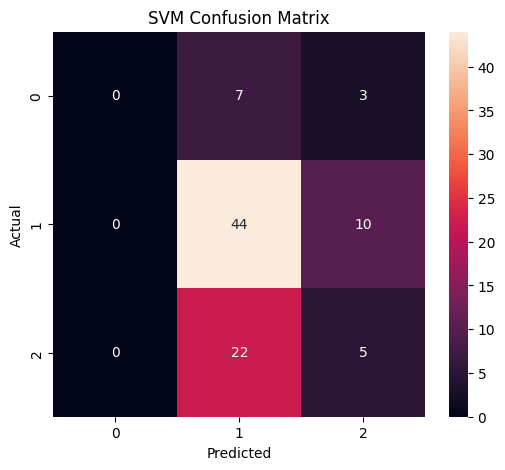

In [58]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

In [60]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.604396,0.466248
1,Naive Bayes,0.593407,0.441986
2,SVM,0.538462,0.477113


In [61]:
results.to_csv("../results/baseline_results.csv", index=False)